# Advanced Customer Segmentation using K-Means, PCA and Cluster Evaluation

## Author: [Your Name]

This notebook performs advanced customer segmentation using K-Means clustering with feature engineering, PCA dimensionality reduction, and cluster evaluation techniques such as Silhouette Score.

In [11]:
import kagglehub

path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Dataset path:", path)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Dataset path: /kaggle/input/customer-segmentation-tutorial-in-python


## Load Dataset

In [12]:
import pandas as pd
import os

# Locate CSV file
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_path = os.path.join(root, file)

# Load dataset
data = pd.read_csv(csv_path)

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Exploration

In [13]:
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


##  Feature Engineering

In [14]:
# Encode Gender
data['Gender'] = data['Gender'].map({'Male':0, 'Female':1})

# Select all features
X = data[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


## Feature Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Elbow Method (Finding Optimal K)

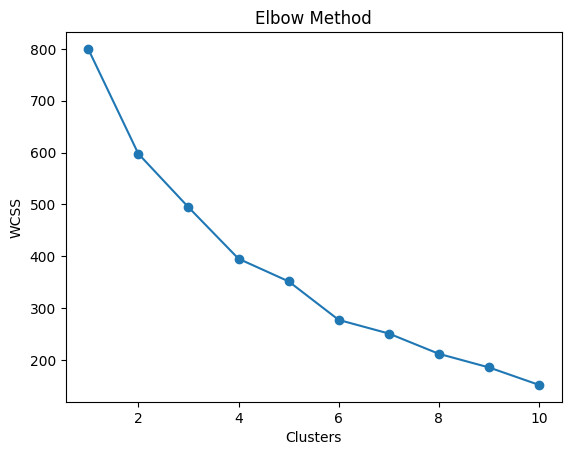

In [16]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

##  Silhouette Score Evaluation

In [17]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.2776035125578272
K=3, Silhouette Score=0.2576199805135528
K=4, Silhouette Score=0.29010917402310876
K=5, Silhouette Score=0.27191023466188324
K=6, Silhouette Score=0.3347543475669217


## Apply K-Means (K=5)

In [18]:
kmeans = KMeans(n_clusters=5, random_state=42)

y_kmeans = kmeans.fit_predict(X_scaled)

data['Cluster'] = y_kmeans

## PCA for Visualization

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.33690046 0.26230645]


##  2D Visualization

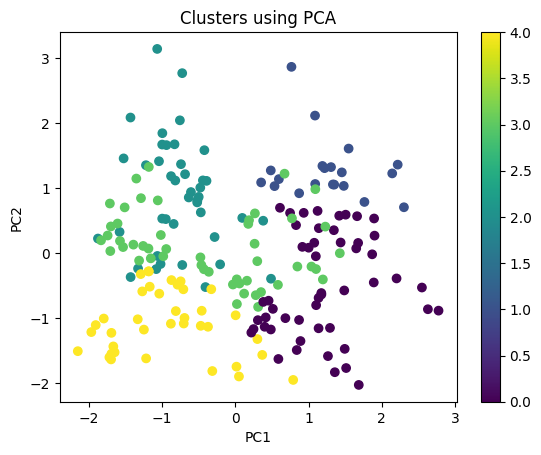

In [20]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_kmeans)
plt.title('Clusters using PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar()
plt.show()

##  3D Visualization

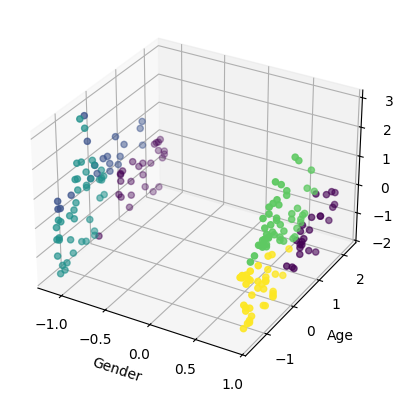

In [21]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_scaled[:,0], X_scaled[:,1], X_scaled[:,2], c=y_kmeans)

ax.set_xlabel('Gender')
ax.set_ylabel('Age')
ax.set_zlabel('Income')

plt.show()

##  Cluster Analysis

In [22]:
data.groupby('Cluster').mean()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,65.333333,0.490196,56.470588,46.098039,39.313725
1,159.500000,0.000000,39.500000,85.150000,14.050000
2,100.809524,0.000000,28.690476,60.904762,70.238095
3,151.510204,1.000000,37.897959,82.122449,54.448980
4,50.526316,1.000000,27.315789,38.842105,56.210526
